# Lab 3 — Support Vector Machines
Part 1 knn from scratch
in Lab2 and Lab3 we implemented linear and logistic regression and svm using gradient descent : so with optimization and leaning parameters and find the decision boundary 
in this lab we will see a new philosophie ,   building a  lazy resuable machine learning estimator 
We will implment k-nearest neighbors  from scratch 
.......
# setup 
We'll work with BankNote_Authentication dataset the task is to  predict the quuality ....
First the standard imports__numpy/pandas for datahandling, matplotlib for  ploting, and a few sklearn utilities we'll resue StandardScaler, train_test_split,accuarcy score ,and KNeigh  ...


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



In [15]:
df = pd.read_csv("magic04.data", header=None)

df.columns = [
    "fLength",
    "fWidth",
    "fSize",
    "fConc",
    "fConc1",
    "fAsym",
    "fM3Long",
    "fM3Trans",
    "fAlpha",
    "fDist",
    "class"
]

In [16]:
shape = df.shape
print(f"The dataset shape:{shape}\n")
print(f"n_features: {shape[1]-1} , n_samples: {shape[0]}\n")
print(f"data set first 5 samples:{df.head()}")
print(f"print the data set info :\n{df.info()}\n")
print(f"print data set description:{df.describe()}")

The dataset shape:(19020, 11)

n_features: 10 , n_samples: 19020

data set first 5 samples:    fLength    fWidth   fSize   fConc  fConc1     fAsym  fM3Long  fM3Trans  \
0   28.7967   16.0021  2.6449  0.3918  0.1982   27.7004  22.0110   -8.2027   
1   31.6036   11.7235  2.5185  0.5303  0.3773   26.2722  23.8238   -9.9574   
2  162.0520  136.0310  4.0612  0.0374  0.0187  116.7410 -64.8580  -45.2160   
3   23.8172    9.5728  2.3385  0.6147  0.3922   27.2107  -6.4633   -7.1513   
4   75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277  28.5525   21.8393   

    fAlpha     fDist class  
0  40.0920   81.8828     g  
1   6.3609  205.2610     g  
2  76.9600  256.7880     g  
3  10.4490  116.7370     g  
4   4.6480  356.4620     g  
<class 'pandas.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize  

In [18]:
X= df.drop(columns="class")
y = df["class"].map({"g":1,"h":0})
print(X.shape)
print(y.shape)
print(y.value_counts())

(19020, 10)
(19020,)
class
1    12332
0     6688
Name: count, dtype: int64


In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"training shape:{X_train.shape}")
print(f"Test training shape: {X_test.shape}")

training shape:(15216, 10)
Test training shape: (3804, 10)


# Data plot 
before choosing any model  we should see how the data is distributed, and in here we have 4 feature so 4D space and since
we cannot plot so we will plot the 6 different 2D combination and the 
4 3D combination  so u can take an overview and the knn intuition becommes clearer

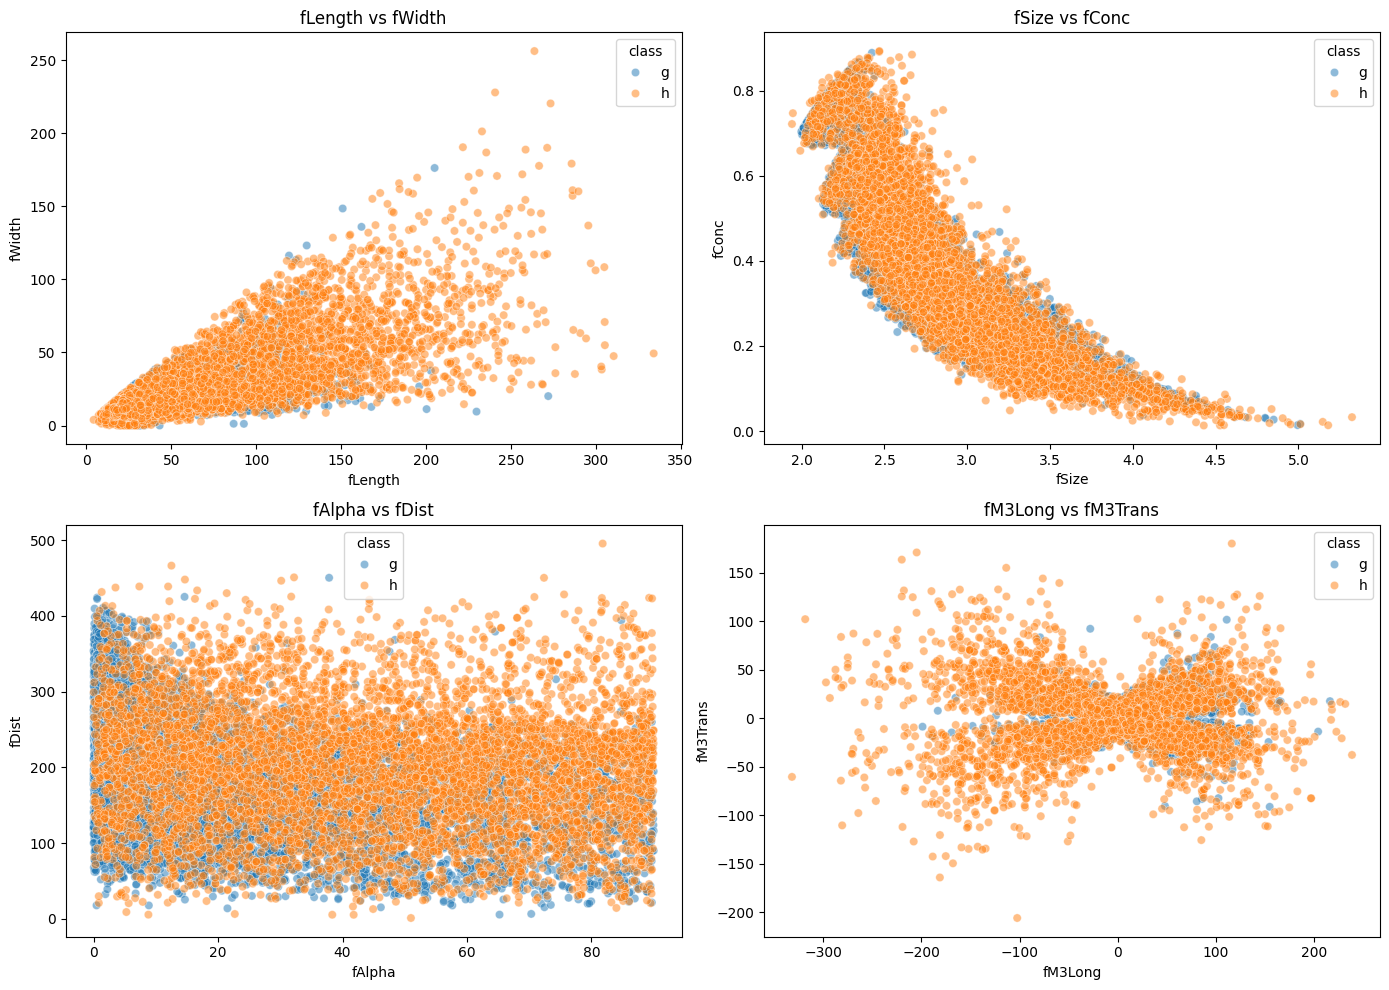

In [21]:
pairs = [
    ("fLength", "fWidth"),
    ("fSize", "fConc"),
    ("fAlpha", "fDist"),
    ("fM3Long", "fM3Trans")
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (x_feature, y_feature) in zip(axes.flat, pairs):
    sns.scatterplot(
        data=df,
        x=x_feature,
        y=y_feature,
        hue="class",
        alpha=0.5,
        ax=ax
    )

    ax.set_title(f"{x_feature} vs {y_feature}")

plt.tight_layout()
plt.show()

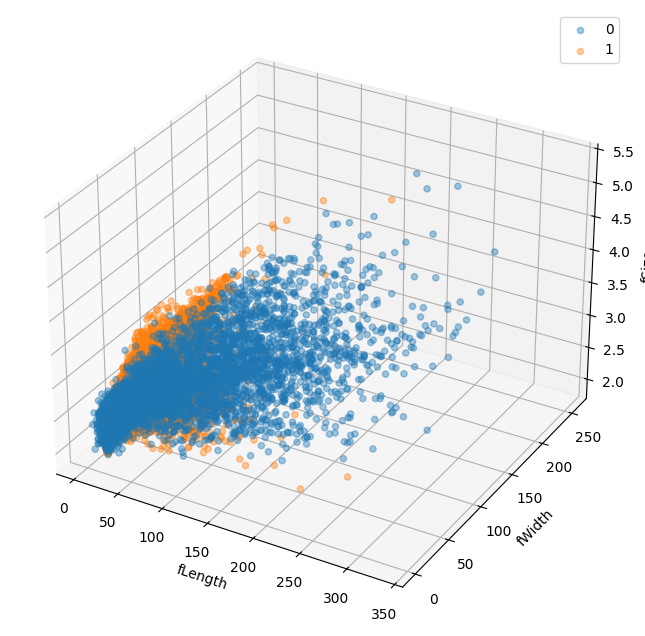

In [22]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for label in [0, 1]:
    subset = df[y == label]

    ax.scatter(
        subset["fLength"],
        subset["fWidth"],
        subset["fSize"],
        label=str(label),
        alpha=0.4
    )

ax.set_xlabel("fLength")
ax.set_ylabel("fWidth")
ax.set_zlabel("fSize")

ax.legend()
plt.show()

In [ ]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)
X_3d = pca.fit_transform(X_scaled)

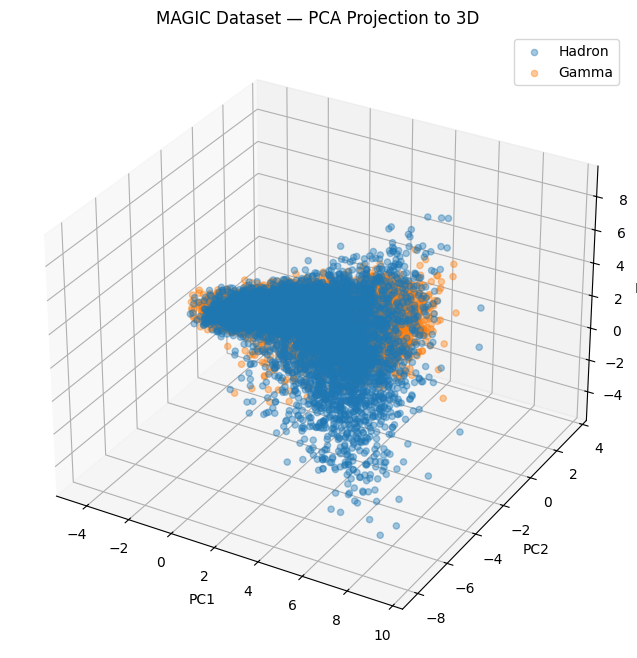

In [25]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for label in [0, 1]:
    mask = y == label

    ax.scatter(
        X_3d[mask, 0],
        X_3d[mask, 1],
        X_3d[mask, 2],
        label="Gamma" if label == 1 else "Hadron",
        alpha=0.4
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("MAGIC Dataset — PCA Projection to 3D")
ax.legend()

plt.show()

# 5 Define the metric  
sicne the knn is to  classify based on the vote of the k nearset so we need metric notion and the most intutive is the  euclidean and as most of u  has done the prepa so for  sure u do know more so for that i need u to play with so 
# What to implent
impelent distance(X1,X2,metic:str="euclidean",**metric_params)


In [26]:
def distance(
    X1: np.ndarray,
    X2: np.ndarray,
    metric: str = "euclidean",
    **metric_params
) -> np.ndarray:

    # X1: (n_samples_1, n_features)
    # X2: (n_samples_2, n_features)

    diff = X1[:, np.newaxis, :] - X2[np.newaxis, :, :]
    #       (n1, 1, f)          (1, n2, f)
    #              ↓ broadcasting
    #              (n1, n2, f)

    if metric == "euclidean":
        return np.sqrt(np.sum(diff ** 2, axis=2))

    elif metric == "minkowski":
        p = metric_params.get("p", 2)
        return np.sum(np.abs(diff) ** p, axis=2) ** (1 / p)

    elif metric == "chebyshev":
        return np.max(np.abs(diff), axis=2)

    else:
        raise ValueError(
            f"Unknown metric {metric}. "
            "Choose from ['euclidean', 'minkowski', 'tchybechev']"
        )

# Building Resuable KNN Estimator

In [29]:
class KNNClassifier:

    def __init__(
        self,
        k: int = 5,
        metric: str = "euclidean",
        weights: str = "uniform",
        **metric_params
    ):
        if weights not in ("uniform", "distance"):
            raise ValueError(
                f"Unknown weights '{weights}'. "
                "Choose from ['uniform', 'distance']"
            )

        self.k = k
        self.metric = metric
        self.metric_params = metric_params
        self.weights = weights

        self.X_ = None
        self.y_ = None

    def fit(self, X, y):
        self.X_ = np.asarray(X)
        self.y_ = np.asarray(y)

        return self

    def _distance(self, X1, X2):
        return distance(
            X1,
            X2,
            metric=self.metric,
            **self.metric_params
        )

    def _get_neighbors(self, distances):
        return np.argsort(distances, axis=1)[:, :self.k]

    def _majority_vote(self, neighbor_indices):
        return self.y_[neighbor_indices]

    def predict(self, X):

        X = np.asarray(X)

        distances = self._distance(X, self.X_)

        neighbor_indices = self._get_neighbors(distances)

        neighbor_classes = self.y_[neighbor_indices]

        # Uniform voting
        if self.weights == "uniform":

            predictions = np.array([
                np.bincount(classes).argmax()
                for classes in neighbor_classes
            ])

            return predictions

        # Distance-weighted voting
        elif self.weights == "distance":

            neighbor_distances = np.take_along_axis(
                distances,
                neighbor_indices,
                axis=1
            )

            weights = 1 / (neighbor_distances + 1e-6)

            n_classes = np.max(self.y_) + 1

            scores = np.zeros(
                (X.shape[0], n_classes)
            )

            for c in range(n_classes):
                scores[:, c] = np.sum(
                    weights * (neighbor_classes == c),
                    axis=1
                )

            predictions = np.argmax(scores, axis=1)

            return predictions
    def __call__(self, X:np.ndarray)->np.ndarray:
        return self.predict(X)


# 14. First real experiment

In [30]:
knn = KNNClassifier(k=5)
knn.fit(X_train,y_train)
y_pred = knn(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.59      0.69      1338
           1       0.81      0.92      0.86      2466

    accuracy                           0.81      3804
   macro avg       0.81      0.76      0.77      3804
weighted avg       0.81      0.81      0.80      3804



# Classication report  and confusion matrix

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.59      0.69      1338
           1       0.81      0.92      0.86      2466

    accuracy                           0.81      3804
   macro avg       0.81      0.76      0.77      3804
weighted avg       0.81      0.81      0.80      3804



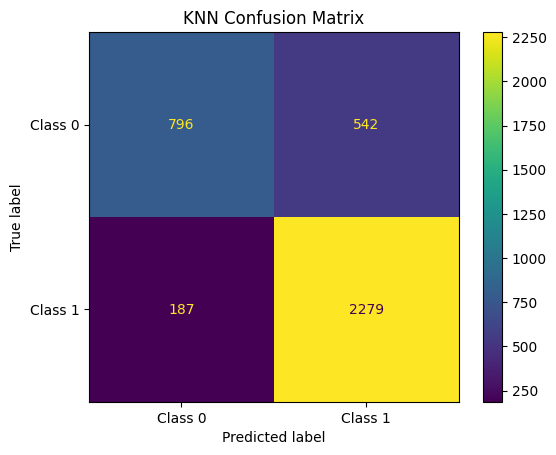

In [32]:
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Class 0","Class 1"])

disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()

# Understanding k
This experiment is  for understanding the effect of k .We are not using the test set too choose the final model

In [33]:
k_values = [1, 3, 5, 7, 11, 15,17,21]
accuracies = []

for k in k_values:
    knn = KNNClassifier(k=k)
    knn.fit(X_train,y_train)
    y_pred = knn(X_test)
    acc = accuracy_score(y_test,y_pred)*100
    accuracies.append(acc)
accuracies

    

[78.15457413249212,
 80.28391167192429,
 80.8359621451104,
 80.78338590956888,
 81.01997896950579,
 80.91482649842271,
 80.80967402733964,
 80.86225026288118]

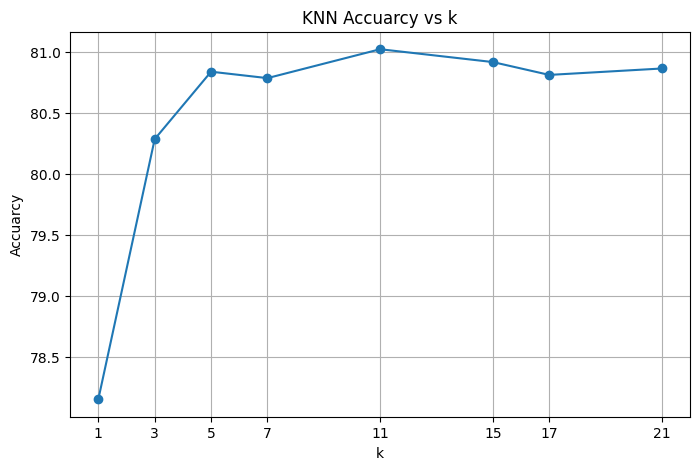

In [34]:
plt.figure(figsize=(8,5))
plt.plot(k_values,accuracies,marker="o")

plt.xlabel("k")
plt.ylabel("Accuarcy")
plt.title("KNN Accuarcy vs k")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

# Scaling experiment
And this is where Banknote Authentification is  useful  becauseits numerical features have different distribution/scales
we  will demonstrate 
KNN
without scaling
        ↓
distances
        ↓
some features can dominate
And as usual we dont fit the scaler on X_test : Put in Mind dont forget

In [35]:
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [36]:
accuracies_scaler = []
for k in k_values:
    knn_ = KNNClassifier(k=k)
    knn_.fit(X_train_scaled,y_train)
    y_pred = knn_(X_test_scaled)
    acc = accuracy_score(y_test,y_pred)*100
    accuracies_scaler.append(acc)
accuracies_scaler

[81.20399579390116,
 82.86014721345951,
 83.62250262881177,
 83.88538380651946,
 83.91167192429022,
 84.30599369085174,
 84.06940063091483,
 83.937960042061]

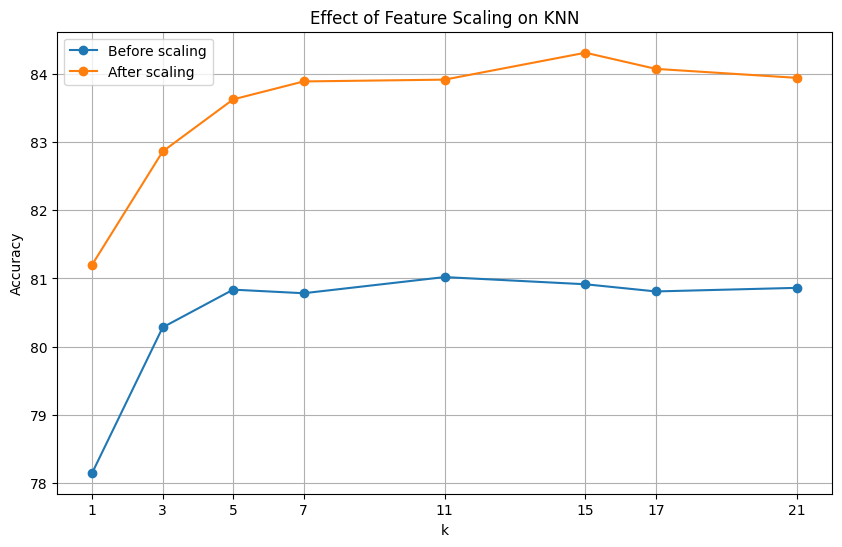

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    accuracies,
    marker="o",
    label="Before scaling"
)

plt.plot(
    k_values,
    accuracies_scaler,
    marker="o",
    label="After scaling"
)

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Effect of Feature Scaling on KNN")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

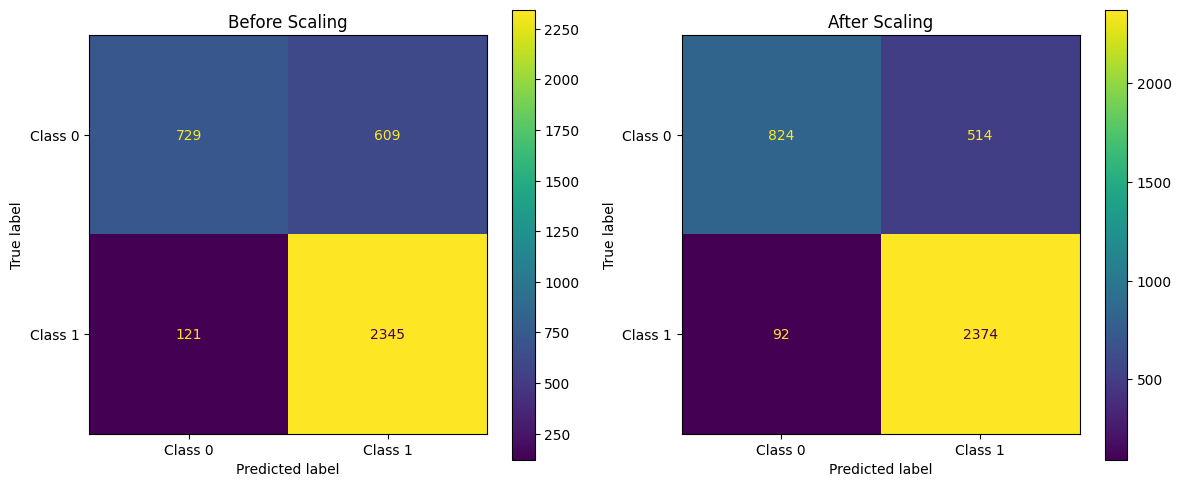

In [38]:
knn_before = KNNClassifier(k =17)
knn_before.fit(X_train,y_train)
y_pred = knn_before(X_test)

knn_scaled = KNNClassifier(k=17)
knn_scaled.fit(X_train_scaled,y_train)
y_pred_scaled = knn_scaled(X_test_scaled)

cm_before = confusion_matrix(y_test, y_pred)
cm_scaled = confusion_matrix(y_test, y_pred_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    cm_before,
    display_labels=["Class 0", "Class 1"]
).plot(ax=axes[0])

axes[0].set_title("Before Scaling")

ConfusionMatrixDisplay(
    cm_scaled,
    display_labels=["Class 0", "Class 1"]
).plot(ax=axes[1])

axes[1].set_title("After Scaling")

plt.tight_layout()
plt.show()

# Experiment  the different metric , different weights and k

In [ ]:
metrics = ["euclidean", "minkowski", "chebyshev"]
weights = ["uniform", "distance"]

results = {}

for metric in metrics:

    for weight in weights:

        key = f"{metric}_{weight}"
        results[key] = []

        for k in k_values:

            if metric == "minkowski":
                knn = KNNClassifier(
                    k=k,
                    metric=metric,
                    weights=weight,
                    p=3
                )
            else:
                knn = KNNClassifier(
                    k=k,
                    metric=metric,
                    weights=weight
                )

            knn.fit(X_train_scaled, y_train)

            y_pred = knn(X_test_scaled)

            accuracy = np.mean(y_pred == y_test)

            results[key].append(accuracy)

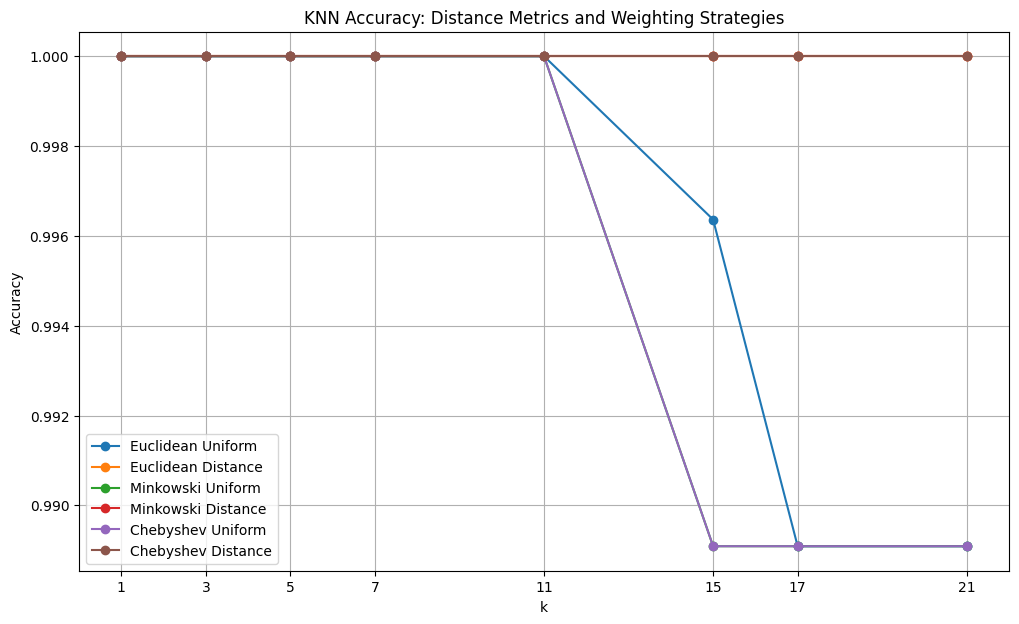

In [96]:
plt.figure(figsize=(12, 7))

for key, accuracies_metric in results.items():

    plt.plot(
        k_values,
        accuracies_metric,
        marker="o",
        label=key.replace("_", " ").title()
    )

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy: Distance Metrics and Weighting Strategies")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

# 18. Final reflection

We finish with conceptual questions rather than another coding exercise.

For example:

Question 1

Why is KNN called a lazy learner?

Question 2

Why does fit() look very different from SVM or Logistic Regression?

Question 3

Why does feature scaling matter for KNN?

Question 4

What happens when k is too small?

Question 5

What happens when k is too large?

Question 6

What is one advantage and one disadvantage of KNN compared with SVM?